simple Linear_regression.ipynb

#Lab content: Linear regression using median_house_price and median_income

#Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Get The Dataset

In [ ]:
import pandas as pd
housing = pd.read_csv("/content/drive/MyDrive/Dataset/housing.csv")
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


#Visualize the dataset to get insights

correlation co-efficent

In [ ]:
#we can check corrrelation among the features. Correlation specify the significance of each feature in the dataset.
#If a feature is not significant enough, we can drop the feature from the dataset, droping feature will reduce the dimentionality of our
#dataset; this will be memory efficient and time efficient to process the dataset.



#here's a function to find correlation
def find_correlation(housing_numeric):
  # computing standard correlation coefficient
  corr_matrix = housing_numeric.corr()
  # fetch and return attribute correlates
  # with the median housing value
  return corr_matrix["median_house_value"].sort_values(
    ascending=False)



In [ ]:
housing_numeric = housing.drop("ocean_proximity", axis=1)
cm=housing_numeric.corr()

In [ ]:
#correlation can be calculated for only those features that contans numerical value. we have to drop those columns that are not numerical
# drop ocean_proximity column
housing_numeric = housing.drop("ocean_proximity", axis=1)
# find correlation coefficient
cor_coef = find_correlation(housing_numeric)
print("Correlation Coefficient::", cor_coef)

Correlation Coefficient:: median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


scatter diagram

<Axes: xlabel='median_income', ylabel='median_house_value'>

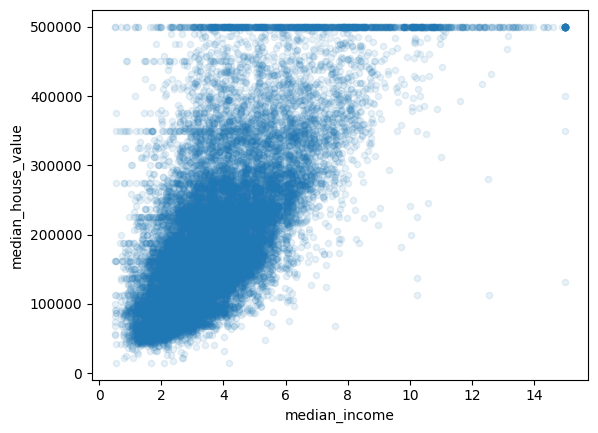

In [ ]:
# scatter plot diagram
housing.plot(kind='scatter',
             x="median_income", y="median_house_value",
             alpha=0.1)

In [ ]:
# copy median_income and median_house_value
housing_selected = housing[['median_income', 'median_house_value']].copy()

In [ ]:
Y=housing_selected[['median_house_value']].copy()
Y

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0
...,...
20635,78100.0
20636,77100.0
20637,92300.0
20638,84700.0


In [ ]:
X=housing_selected[['median_income']].copy()
X

,median_income
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


In [ ]:
from sklearn.model_selection import train_test_split

# Example data
# X = your feature matrix (e.g., numpy array or pandas DataFrame)
# Y = your target array (e.g., numpy array or pandas Series)

# Split data into 80% train and 20% test sets (you can adjust test_size)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Now you have:
# X_train, Y_train for training
# X_test, Y_test for testing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [ ]:
from sklearn.linear_model import LinearRegression
# linear regression model for best fit
# Fit linear regression
model = LinearRegression()
model.fit(X_train, Y_train)

# Predict on test set
Y_pred = model.predict(X_test)

# Calculate MAE and RMSE
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 62990.8653
RMSE: 84209.0124


In [ ]:
from sklearn.ensemble import RandomForestRegressor
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Predict on test set
Y_pred = rf.predict(X_test)

# Calculate MAE and RMSE
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print(f"Random Forest MAE: {mae:.4f}")
print(f"Random Forest RMSE: {rmse:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest MAE: 71316.7029
Random Forest RMSE: 97018.0455


#Polynomial Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

In [ ]:
# Split data into 80% train and 20% test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Transform the features to include polynomial terms (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
# Train the Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, Y_train)

LinearRegression()

In [ ]:
# Predict on the test set
Y_pred_poly = poly_model.predict(X_test_poly)

# Calculate performance metrics
poly_mae = mean_absolute_error(Y_test, Y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(Y_test, Y_pred_poly))
poly_r2 = poly_model.score(X_test_poly, Y_test)

# Print the results
print(f"Polynomial Regression MAE: {poly_mae:.4f}")
print(f"Polynomial Regression RMSE: {poly_rmse:.4f}")
print(f"Polynomial Regression R2 Score: {poly_r2:.4f}")

Polynomial Regression MAE: 62829.1559
Polynomial Regression RMSE: 83861.3897
Polynomial Regression R2 Score: 0.4633


#K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(poly_model, X_train_poly, Y_train,
                         scoring="neg_root_mean_squared_error", cv=5)
rmse_scores = -scores
print("RMSE per fold:", rmse_scores)
print("Average RMSE:", np.mean(rmse_scores))

RMSE per fold: [83715.16108213 81788.05984802 83935.17103275 82793.30575027
 84018.3663177 ]
Average RMSE: 83250.01280617334
